In [1]:
import os
os.environ['EXO_LD_PATH'] = '/Users/tylergordon/research/exotic_ld_data'

import pickle
import numpy as np
import matplotlib.pyplot as plt
from multiprocess import Pool

import sys
sys.path.append('../get_planet_params/')
from fit_wlc import fit, load_priors_and_parameters
import distributions

# load priors 
priors_d, st_params = load_priors_and_parameters(
    'TOI-270 d', 
    ('van_eylen', '2021'), 
    ('van_eylen', '2021')
)

priors_b, st_params = load_priors_and_parameters(
    'TOI-270 b', 
    ('van_eylen', '2021'), 
    ('van_eylen', '2021')
)

# change priors or initial points if necessary 
# e.g. priors['orbeccen'] = distributions.uniform(0, 1, init=0.01)

In [155]:
# build control dictionaries for each lightcurve (just one if not using G395H)
control_dict_nrs1 = {
    
    # eureka or jedi
    'pipeline': 'eureka',
    
    'priors': [priors_d, priors_b],
    'stellar_parameters': st_params,
    
    # this is the directory that all the input files are located in
    'data_directories': [
        '/Users/tylergordon/research/HBM/volga/TOI-270_d/4098_17/S3_nrs1_ap4_bg7_SpecData.h5'
    ],
    
    # use this to mask any columns that look like they got a bad background subtraction
    'columns_to_mask': [],
    
    # for G395H, will need to add support for other detectors/dispersers 
    'detector': 'nrs1',
    
    # number of MCMC samples and number to crop off beginning of chains for burn-in
    'samples': 10_000,
    'burnin': 5_000,
    
    # number of processors to use: 2 seems to be best on my computer for some reason.
    'num_proc': 2,
    
    # order of a polynomial trend for the out-of-transit flux 
    'polyorder': 1,
    
    # whether to show the MCMC progress bar or not 
    'show_progress_bar': True,
    
    # number of processors to use for spectral lightcurve fitting 
    'num_proc_slc': 12,
    
    # number of samples for white lightcurve fitting
    'samples_slc': 5000
}

control_dict_nrs2 = {
    'pipeline': 'eureka',
    'priors': [priors_d, priors_b],
    'stellar_parameters': st_params,
    'data_directories': [
        '/Users/tylergordon/research/HBM/volga/TOI-270_d/4098_17/S3_nrs2_ap3_bg6_SpecData.h5'
    ],
    'columns_to_mask': [],
    'detector': 'nrs2',
    'samples': 10_000,
    'burnin': 5_000,
    'num_proc': 2,
    'polyorder': 1,
    'show_progress_bar': True,
    'num_proc_slc': 12,
    'samples_slc': 5000
}

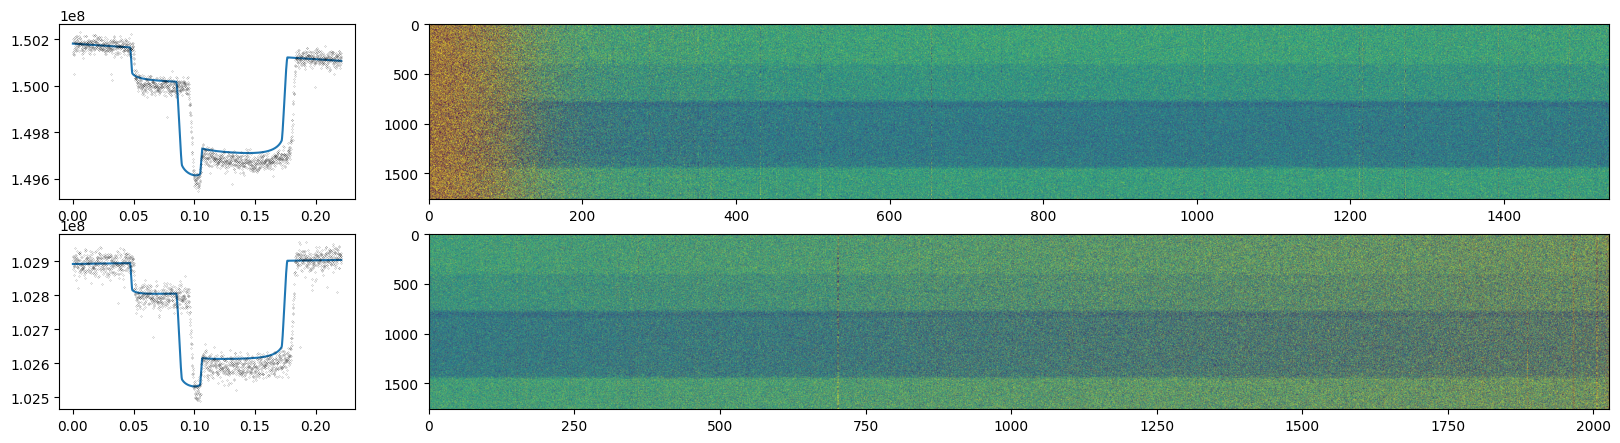

In [10]:
# plot the white lightcurves along with the model corresponding to the initial parameters for the MCMC fit 
# also plots the time vs. x-pixel images for identifying bad columns or other artifacts 

from fit_wlc import check_initial_state, prep_data

times_nrs1, spects_nrs1, errs_nrs1, _, specs_nrs1, flux_nrs1, _= prep_data(control_dict_nrs1)
initial_models_nrs1 = check_initial_state(control_dict_nrs1)

times_nrs2, spects_nrs2, errs_nrs2, _, specs_nrs2, flux_nrs2, _ = prep_data(control_dict_nrs2)
initial_models_nrs2 = check_initial_state(control_dict_nrs2)

for i in range(len(times_nrs1)):
    
    fig, axs = plt.subplots(2, 2, figsize=(20, 5), gridspec_kw={'hspace': 0.2, 'wspace': 0.1, 'width_ratios':(0.2, 0.8)})
    
    axs[0, 0].plot(times_nrs1[i], initial_models_nrs1[i])
    axs[0, 0].plot(times_nrs1[i], flux_nrs1[i], 'k.', markersize=0.2)
    axs[0, 1].imshow(spects_nrs1[i] / np.nanmedian(spects_nrs1[i], axis=0), aspect='auto', vmin=0.99, vmax=1.01)

    axs[1, 0].plot(times_nrs2[i], initial_models_nrs2[i])
    axs[1, 0].plot(times_nrs2[i], flux_nrs2[i], 'k.', markersize=0.2)
    axs[1, 1].imshow(spects_nrs2[i] / np.nanmedian(spects_nrs2[i], axis=0), aspect='auto', vmin=0.99, vmax=1.01)

In [11]:
import imp
import fit_wlc
import wlc_utils
imp.reload(fit_wlc)
imp.reload(wlc_utils)
from fit_wlc import fit

# run the fits once everything looks good 

wlc_res_nrs1 = fit(control_dict_nrs1)
wlc_res_nrs2 = fit(control_dict_nrs2)

100%|█| 10000/10000 
100%|█| 10000/10000 


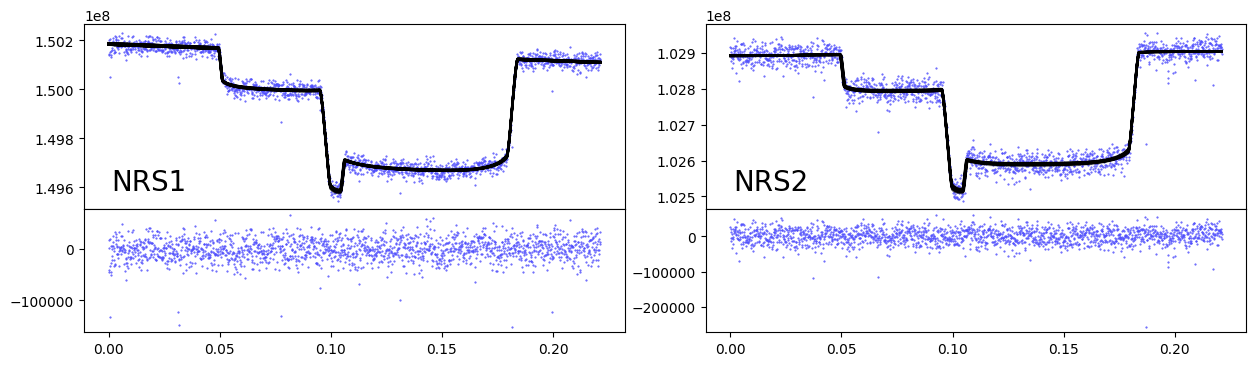

In [13]:
from fit_wlc import get_model_samples

fig, axs = plt.subplots(2, 2, figsize=(15, 4), gridspec_kw={'height_ratios': (0.6, 0.4), 'hspace': 0.0, 'wspace': 0.15}, sharex=True)

axs[0, 0].annotate('NRS1', fontsize=20, xy=(0.05, 0.1), xycoords='axes fraction')
axs[0, 1].annotate('NRS2', fontsize=20, xy=(0.05, 0.1), xycoords='axes fraction')

for res_nrs1, res_nrs2 in zip(wlc_res_nrs1, wlc_res_nrs2):
    
    models_nrs1 = get_model_samples(res_nrs1, n=100)

    axs[0, 0].plot(res_nrs1['time'], res_nrs1['flux'], '.', color=plt.cm.rainbow(0.1), markersize=1.0)
    [axs[0, 0].plot(res_nrs1['time'], m, color='k', alpha=0.3) for m in models_nrs1];
    axs[1, 0].plot(res_nrs1['time'], res_nrs1['flux'] - np.mean(models_nrs1, axis=0), '.', color=plt.cm.rainbow(0.1), markersize=1.0)

    models_nrs2 = get_model_samples(res_nrs2, n=100)

    axs[0, 1].plot(res_nrs2['time'], res_nrs2['flux'], '.', color=plt.cm.rainbow(0.1), markersize=1.0)
    [axs[0, 1].plot(res_nrs2['time'], m, color='k', alpha=0.3) for m in models_nrs2];
    axs[1, 1].plot(res_nrs2['time'], res_nrs2['flux'] - np.mean(models_nrs2, axis=0), '.', color=plt.cm.rainbow(0.1), markersize=1.0)

In [194]:
import imp
import fit_slc
imp.reload(fit_slc)
from fit_slc import fit

slc_res_nrs1 = fit(wlc_res_nrs1, samples=5000)
slc_res_nrs2 = fit(wlc_res_nrs2, samples=5000)

running bands 61-67 of 67                                   

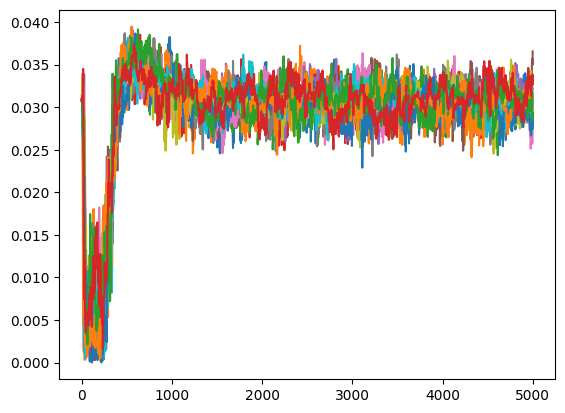

In [206]:
plt.plot(slc_res_nrs2['posteriors'][60]['r1']);

<ErrorbarContainer object of 3 artists>

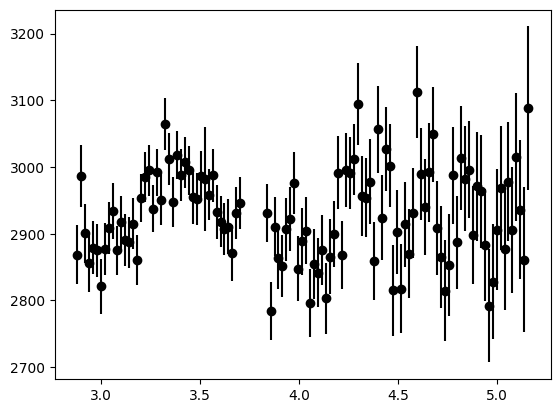

In [197]:
binned_wavs = np.concatenate([slc_res_nrs1['wavs'], slc_res_nrs2['wavs']])
depths = np.array([np.median(p['r0'][3000:]) for p in slc_res_nrs1['posteriors'] + slc_res_nrs2['posteriors']])
errs = np.array([np.std(p['r0'][3000:]) for p in slc_res_nrs1['posteriors'] + slc_res_nrs2['posteriors']])

plt.plot(binned_wavs, depths**2 * 1e6, 'ko')
plt.errorbar(binned_wavs, depths**2 * 1e6, yerr=errs * 2 * depths * 1e6, ls='none', color='k')

<ErrorbarContainer object of 3 artists>

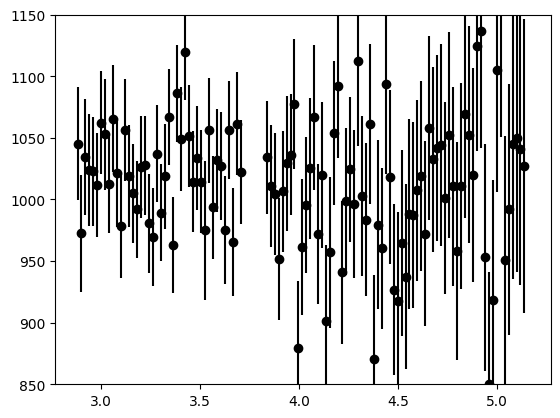

In [209]:
binned_wavs = np.concatenate([slc_res_nrs1['wavs'], slc_res_nrs2['wavs']])
depths = np.array([np.median(p['r1'][3000:]) for p in slc_res_nrs1['posteriors'] + slc_res_nrs2['posteriors']])
errs = np.array([np.std(p['r1'][3000:]) for p in slc_res_nrs1['posteriors'] + slc_res_nrs2['posteriors']])

plt.ylim(850, 1150)
plt.plot(binned_wavs, depths**2 * 1e6, 'ko')
plt.errorbar(binned_wavs, depths**2 * 1e6, yerr=errs * 2 * depths * 1e6, ls='none', color='k')

In [ ]:
1 / 0.00465047

In [ ]:
type(priors_b['ratror']) == distributions.uniform_prior

In [24]:
np.sum([1, 2, 3])

6